# TU Wien | 307.511-2026S  Aircraft Design 2 | Group 1

## Group Members
- [ ] Diego Medeiros Dalla Costa
- [ ] Nikita Starikov
- [ ] Michael Riedl
- [ ] Matthias Frenzl


####  1. Introduction

Write a small contextualization for the project (what is the objective?) and list the relevant specifications given for the assignment.

####  2. Short Review of Results from Aircraft Design I

Please provide the main results from the previous semester, it should include:

- [ ] Design masses: MTOM, OEM and Fuel mass along with preliminary Payload vs. Range diagram,
- [ ] $C_L$, $C_D$ and $L/D$ assumptions,
- [ ] Final $P/W$ vs. $W/S$ diagram, highlighting the selected values for the baseline and stretch designs,
- [ ] LH2 system volumes (and masses if already computed),
- [ ] 3-side view of the aircraft configuration.

In [289]:
# Put the parameters and results from the previous report here:


In [290]:
# Global Imports
from IPython.display import display, Math
from math import *
import math
from matplotlib import pyplot as plt
import numpy as np

####  3. Initial Drag Estimation

In this chapter the revision of the parasite drag must be carried out using the three methods described in lecture and available in the handout. Discuss which method better estimates the parasite drag in your opinion and adopt a new value for $C_{D_0}$ based on your new results. How does it compare with your initial guess from ACDI?

Following the determination of the parasite drag, compute the drag polar for cruise, take-off and landing configurations by adding the lift-induced drag and any additional drag due to high-lift devices, landing gear, compressibility, etc.

Determine your $L/D$ ratio for the conditions: Cruise, Take-Off and Landing using a $L/D$ vs. $C_L$ diagram. Do the values match your assumption from ACDI? If there are large discrepancies, verify that the aircraft is able to meet the requirements in the $P/W$ vs. $W/S$ diagram by adjusting it to the new values.

In [291]:
# Code

# Zero lift drag

#Values of the Airplane
mTO=22710 # Maximum takeoff mass in kg of the stretch variant
mTO_lbs=mTO*2.205 # Maximum takeoff mass in lbs of the stretch variant
S=50 # Wing area in m^2
S_ft2=S*10.7639 # Wing area in m^2 converted to ft^2
lf=34.1 # Fuselage length in m
df=2.69 # Fuselage diameter in m
dProp=2.71 # Propeller diameter in m
lProp=0.39 # Motor length in m
dT=1.15 # Tank diameter in m
lT=3.04 # Tank length in m
S_HT=9.85 # Horizontal tail area in m^2
S_VT=6.9 # Vertical tail area in m^2
P_TO=3749 # Power at takeoff in kW
kin_visc_cruise=10.13e-6 # Kinematic viscosity at cruise conditions in 29000 ft in m^2/s
v_cruse=156.8 # Cruise speed in m/s
AR=8    # Aspect ratio

#1.) Roskam
a=-2.5229
b=1
c=-0.0866
d=0.8099
S_wet=10**(c+d*math.log10(mTO_lbs))
s=10**(a+b*math.log10(S_wet))
CD_0_Roskam = s/S_ft2

#2.) Main components
CD_W=0.007  # Wing
CD_F=0.0028 # Fuselage
CD_Prop=0.006 # Propeller
CD_T=0.004 # Tanks
CD_E=0.008 # Empennage
Delta_CD=1.15 # Interference factor with 15% increase
W_MC=S
F_MC=0.75*math.pi*df*lf
P_MC=0.75*math.pi*dProp*lProp
T_MC=0.75*math.pi*dT*lT
E_MC=S_HT+S_VT
CD_0_MC=(CD_W*W_MC + CD_F*F_MC + CD_Prop*P_MC + CD_T*T_MC + CD_E*E_MC)/(S*Delta_CD)

#3.) Torenbeek
rw=1
tc=0.12         #Thickness to chord ratio, depending on the airfoil used
phi=0           #Sweep angle in degrees
W_T=0.0054*rw*(1+3*tc*math.cos(phi))
rf=1            #Fuselage Shape factor
wf=2.69         #Fuselage width in m
hf=2.69         #Fuselage height in m
F_T=0.0031*rf*lf*(wf+hf)
rt=1.3*1.1
rn=1
Sn_front=math.pi*dT**2/4
E_T=0.1*rn*Sn_front
r_uc=1.08
Re_f=v_cruse*lf/kin_visc_cruise
r_Re=0.8            #Accoding to Diagram on page 8 of Initail Drag estimation
CD_0_T=r_Re*r_uc*(rt*(W_T+F_T)+E_T)



#Calculation of the drag paraboles 
CL_Cruise=np.linspace(0,0.75,25) #From 0 to maximum CL for cruise
CL_Landing=np.linspace(0,3,25) #From cruise CL to maximum CL for landing
CL_TO=np.linspace(0,2.3,25) #From cruise CL to maximum CL for takeoff

CD_Cruise=CD_0_MC+CL_Cruise**2/(math.pi*AR*0.8)
CD_Landing=CD_0_MC+CL_Landing**2/(math.pi*AR*0.7)+0.075                  #0.075 based on slide 9 with gear down and flaps/slats extended
CD_Landing_without_gear=CD_0_MC+CL_Landing**2/(math.pi*AR*0.7)+0.06    #0.06 based on slide 9 with flaps/slats extended but gear up
CD_TO=CD_0_MC+CL_TO**2/(math.pi*AR*0.75)+0.035                           #0.035 based on slide 9 with gear down and flaps/slats extended
CD_TO_without_gear=CD_0_MC+CL_TO**2/(math.pi*AR*0.75)+0.015              #0.015 based on slide 9 with flaps/slats extended but gear up

L_D_Cruise=CL_Cruise/CD_Cruise
L_D_Landing=CL_Landing/CD_Landing
L_D_Landing_without_gear=CL_Landing/CD_Landing_without_gear
L_D_TO=CL_TO/CD_TO
L_D_TO_without_gear=CL_TO/CD_TO_without_gear



In [292]:
# Results 
display(Math(rf"C_{{D_{{0,\,\mathrm{{Roskam}}}}}} = {CD_0_Roskam:.6f}"))
display(Math(rf"C_{{D_{{0,\,\mathrm{{MC}}}}}} = {CD_0_MC:.6f}"))
display(Math(rf"C_{{D_{{0,\,\mathrm{{Torenbeek}}}}}} = {CD_0_T:.6f}"))
display(Math(rf"(L/D)_{{\max,\,\mathrm{{Cruise}}}} = {max(L_D_Cruise):.2f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

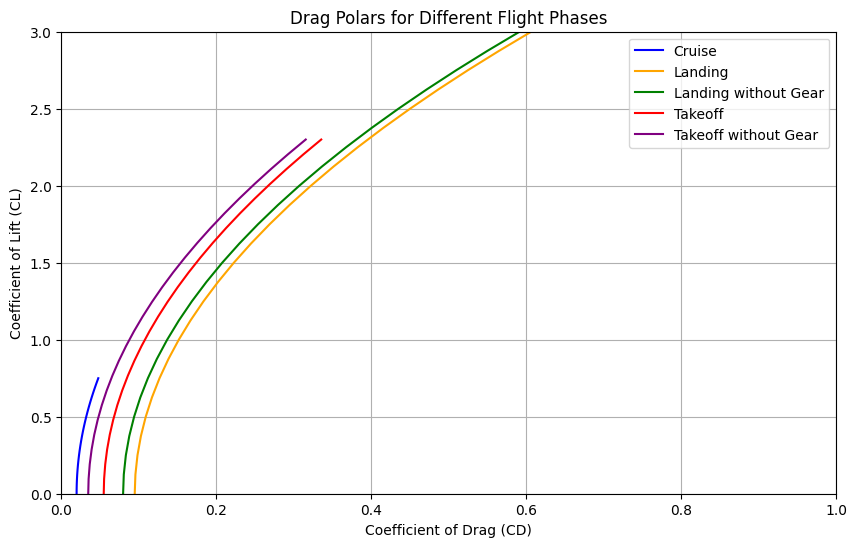

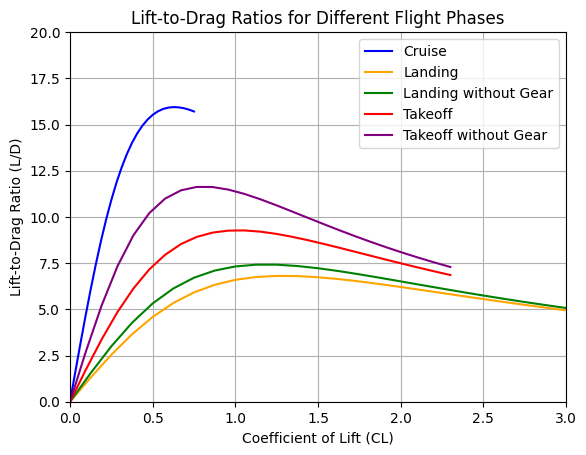

In [293]:
# Plots

#Plotting the drag polars
plt.figure(figsize=(10,6))
plt.plot(CD_Cruise, CL_Cruise, label='Cruise', color='blue')
plt.plot(CD_Landing, CL_Landing, label='Landing', color='orange')
plt.plot(CD_Landing_without_gear, CL_Landing, label='Landing without Gear', color='green')
plt.plot(CD_TO, CL_TO, label='Takeoff', color='red')
plt.plot(CD_TO_without_gear, CL_TO, label='Takeoff without Gear', color='purple')
plt.ylabel('Coefficient of Lift (CL)')
plt.xlabel('Coefficient of Drag (CD)')
plt.title('Drag Polars for Different Flight Phases')
plt.ylim(0,3)
plt.xlim(0,1)
plt.grid()
plt.legend()
plt.show()



plt.plot(CL_Cruise,L_D_Cruise, label='Cruise', color='blue')
plt.plot(CL_Landing,L_D_Landing, label='Landing', color='orange')
plt.plot(CL_Landing,L_D_Landing_without_gear, label='Landing without Gear', color='green')
plt.plot(CL_TO,L_D_TO, label='Takeoff', color='red')
plt.plot(CL_TO,L_D_TO_without_gear, label='Takeoff without Gear', color='purple')
plt.ylabel('Lift-to-Drag Ratio (L/D)')
plt.xlabel('Coefficient of Lift (CL)')
plt.title('Lift-to-Drag Ratios for Different Flight Phases')
plt.ylim(0,20)
plt.xlim(0,3)
plt.grid()
plt.legend()
plt.show()


In [294]:
# Output Variables / Parameter

####  4. Design Airspeeds and V-n Diagram

Determine and/or compute the design speeds for the baseline aircraft (provide justifications):

- $V_{MO}$ and $M_{MO}$
- $V_C$ and $M_C$
- $V_D$ and $M_D$

Once the speeds are known, please provide a graph of the design speeds vs. altitude.

The V-n diagram for the following conditions must be reported:

- Maneuver envelope (clean and landing configuration)
- Gust loads at: Sea level, ceiling altitude and altitude where peak loads occur (three different graphs!)

Maneuver and gust envelopes may be shown in parallel or overlapped. Note that in case of LH2 aircraft, the mass variation is small and therefore computations may be carried out in a simplified way based on the MTOM.

In [ ]:
# Code here
Ma=0.515            #Mach number at cruise conditions in 29000 ft, same as last semester
c=304.484           #Speed of sound at cruise conditions in 29000 ft in m/s
v=c*Ma*1.944        #Cruise speed in knots
v_ms=v/1.944        #Cruise speed in m/s
rho0=1.225          #Air density at sea level in kg/m^3
rho=0.475448           #Air density at cruise conditions in 29000 ft in kg
vEAS=v*math.sqrt(rho/rho0) #Equivalent Airspeed in knots

vc=vEAS/0.8         #Design Cruise Speed in knots, assuming that the cruise speed is 80% of the design cruise speed
vMo=0.85*vc         #Maximum operating speed in knots, assuming that the maximum operating speed is 95% of the design cruise speed
vD=vc+60            #Design dive speed in knots, assuming that the design dive speed is 60 knots above the design cruise speed according to slide 15


Cruise Speed: 189.91 knots EAS, 304.84 knots TAS
Design Cruise Speed: 237.39 knots EAS
Maximum Operating Speed: 201.78 knots EAS
Design Dive Speed: 297.39 knots EAS


In [ ]:
print(f"Cruise Speed: {vEAS:.2f} knots EAS, {v:.2f} knots TAS")
print(f"Design Cruise Speed: {vc:.2f} knots EAS")
print(f"Maximum Operating Speed: {vMo:.2f} knots EAS")
print(f"Design Dive Speed: {vD:.2f} knots EAS")

In [297]:
# Plot here

In [298]:
# Output Variables / Parameter



####  5. Load & Balance

Calculate the mass of the main components of the aircraft, according to the methods presented in the slides of "Detailed Mass Estimation". Using Torenbeek or geometric information, compute the center of gravity location for each component with respect to a reference point. Note that components may be divided into two main groups:

- Fuselage group
- Wing group

With the known masses and centers of gravity, determine the stability limits for the aircraft on ground and in air:

- Longitudinal stability on ground (rearmost and high CG),
- Minimum and maximum nose gear load,
- Tilting stability on ground (foremost and high CG),
- Neutral point at cruise condition.

Once the limits are known, plot the loading (potato) diagrams for the aircraft for the most critical conditions expected (e.g. Design mission, transfer mission, etc.). It should include at least:

- Pax loading (front and back),
- Cargo loading (front and back),
- Fuel loading.

In case of violation of the limits, the wing positioning may be adjusted.

At the end, add to a table the conditions for the foremost and rearmost CG variation during loading, and their respective positions.

In [299]:
# Code here

In [300]:
# Results here

In [301]:
# Plot here

In [302]:
# Output Variables / Parameter

####  6. Lift Distribution and Detailed Drag Estimation

In this section the main objective is to obtain the lift distribution of the wing and calculate a more detailed breakdown of the drag components via XFLR5 and analytical relations.

The wing's lift distribution must be used to estimate the starting location of the stall progression and to verify that the risk of loss of roll control is low.

A $C_L$ vs. $C_D$ polar with the drag build-up is to be presented, it shall include contributions from:

- Wing parasite drag,
- Fuselage,
- HTP and VTP,
- Trim drag,
- Induced drag,
- Nacelles,
- Compressible drag.

Once the aerodynamic polar for the clean aircraft is known, compute the $L/D$ vs. $C_L$ and $L/D$ vs. $M$ polar for different flight altitudes at the initial cruise weight.

In [303]:
# Code here

In [304]:
# Results here

In [305]:
# Plot here

In [306]:
# Output Variables / Parameter


####  7. High-Lift Devices

The High-Lift Devices (HLD) must be chosen and sized to meet the specifications made in ACDI for the Take-Off and Landing assessments.

Based on the wing's planform, regions for application of the HLD must be assigned. A flap system (plain, slotted, double slotted or Fowler flap) and a slat system (standard LE slat, Krüger flap, no leading edge device) must be chosen.

Compute the $C_L$ vs. $\alpha$ curves for take-off and landing configurations using the method presented in class, as well as the $C_L$ vs. $C_D$ and $L/D$ vs. $C_L$ polars.

Please summarize in tables the main parameters for the calculations:

- $C_{L_\alpha}$, $\alpha_0$, $C_{L_{max}}$ and $\Delta\alpha_{C_{L_{max}}}$ without HLD
- Surface areas and dimensions: $S_F/S$, $S_S/S$, $c_F/c$, $c_S/c$
- $\Delta C_{L_{max,F}}$ and $\Delta C_{L_{F,\varphi}}$
- $\Delta C_{L_{max,S}}$
- $\Delta C_{D_{flaps}}$ (including sub-components)

The following figures are mandatory (polars for the three configurations in one plot — clean, take-off and landing):

- Wing planform with flaps/slats assignments
- $C_L$ vs. $\alpha$
- $C_L$ vs. $C_D$ (with and w/o LG)
- $L/D$ vs. $C_L$ (with and w/o LG)

Please add a short discussion about the results.

In [307]:
# Code here

In [308]:
# Results here

In [309]:
# Plot here

In [310]:
# Output Variables / Parameter

#### 8. PEMFC Ancillary System — Power Requirements

Please include the analyses made to compute the required power for the ancillaries of the PEMFC according to the slides (*2024 01 08 PEMFC Ancillary Power v3*). Explain and justify any assumptions and variables that are specific to the operation of your aircraft.

In [311]:
# Code here

In [312]:
# Results here

In [313]:
# Plot here

In [314]:
# Output Variables / Parameter


#### 9. Performance Assessment

This section includes analysis of the performance of your aircraft.

##### Flight Conditions (Handout 1)

- **Level diagrams** for different altitudes starting from sea-level. Conditions:
    - MTOW, max climb ($TR_{throttle} = 0.9$)
    - MTOW, max cruise ($TR_{throttle} = 0.8$)
- **Specific excess thrust (SET) and excess power (SEP)** for climb. Plotted for different altitudes against true airspeed.
- **Optimum airspeeds** (minimum, max SET, max SEP, maximum) to be plotted together with the upper equilibrium airspeed in level flight as a function of altitude ($H$ vs. TAS).
- **Specific air range (SAR) and flight durations (SE)**, using ICA weight. Plotted for different altitudes over true airspeed.
- **Flight envelope** ($H$ vs. TAS) for ICA weight and cruise thrust throttle ratio.

##### Flight Segments (Handout 2)

- Integral climb performance shall be calculated for the fastest climb at ICA.
- Final payload-range diagram based on flight performance results.

In [315]:
# Code here

In [316]:
# Results here

In [317]:
# Plot here

In [318]:
# Output Variables / Parameter

####  10. Direct Operating Costs

Present the estimated annual costs to operate your aircraft using the general parameters defined in the lecture slides. Expected diagrams/graphs and tables:

- Payload-Range diagram overlapped with CASK vs. Range. *Tip: use two y-axes.*
- Table listing main categories and respective annual costs, CASK, percentage of total DOC and estimated seat cost (DOC only) + share of engine price to total aircraft price.
- Break-even passenger count assuming a revenue rate of € 0.10/km and operating range margin assuming a 75% load factor.

In [319]:
# Code here

In [320]:
# Results here

In [321]:
# Plot here

In [322]:
# Output Variables / Parameter

####  11. Conclusion

Final discussion on your project. What were the lessons learned throughout the course? Which aspect/analysis had most impact on the design? What are the main uncertainties regarding your design? How could your aircraft be improved?

#### Automatic Latex Report (.tex file) Generation

In [323]:
# Code here

#### Automatic Latex Presentation (.tex file) Generation

In [324]:
# Code here